In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
model=tf.keras.models.load_model("trained_model.keras")

In [3]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 conv2d_1 (Conv2D)           (None, 128, 128, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 64, 64, 32)       0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 64, 64, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 64, 64, 64)        36928     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 32, 32, 64)       0         
 2D)                                                    

# Visualizing image of test set

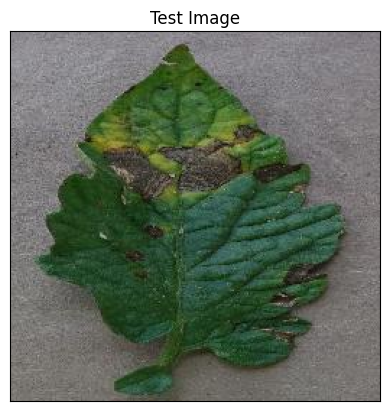

In [4]:
import cv2
image_path="test/TomatoEarlyBlight4.JPG"
img=cv2.imread(image_path)
img=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title("Test Image")
plt.xticks([])
plt.yticks([])
plt.show()

# Testing Model

In [5]:
image=tf.keras.preprocessing.image.load_img(image_path, target_size=(128,128))
input_arr=tf.keras.preprocessing.image.img_to_array(image)

In [6]:
print(input_arr)

[[[133. 131. 136.]
  [134. 132. 137.]
  [142. 140. 145.]
  ...
  [137. 132. 138.]
  [129. 124. 130.]
  [134. 129. 135.]]

 [[134. 132. 137.]
  [138. 136. 141.]
  [133. 131. 136.]
  ...
  [132. 127. 133.]
  [133. 128. 134.]
  [134. 129. 135.]]

 [[142. 140. 145.]
  [140. 138. 143.]
  [129. 127. 132.]
  ...
  [135. 130. 136.]
  [131. 126. 132.]
  [122. 117. 123.]]

 ...

 [[110. 107. 102.]
  [126. 123. 118.]
  [111. 108. 103.]
  ...
  [117. 113. 110.]
  [120. 116. 113.]
  [110. 106. 103.]]

 [[131. 128. 123.]
  [128. 125. 120.]
  [128. 125. 120.]
  ...
  [117. 113. 110.]
  [121. 117. 114.]
  [122. 118. 115.]]

 [[115. 112. 107.]
  [140. 137. 132.]
  [130. 127. 122.]
  ...
  [120. 116. 113.]
  [108. 104. 101.]
  [124. 120. 117.]]]


In [7]:
input_arr.shape

(128, 128, 3)

In [8]:
input_arr=np.array([input_arr])
print(input_arr.shape)

(1, 128, 128, 3)


In [9]:
predictions=model.predict(input_arr)
print(predictions)

1/1 [==============================] - 7s 7s/step
[[1.0824516e-11 9.0184865e-12 4.1584943e-07 5.5837984e-10 2.7126274e-12
  1.3170176e-09 1.2289142e-13 1.8435572e-06 5.3752043e-14 5.1554650e-08
  6.7591744e-12 1.7207820e-04 5.5132273e-06 7.9577092e-08 1.5762079e-11
  9.4451660e-12 4.7112640e-04 1.5011015e-08 1.3329122e-07 2.6293908e-11
  1.7274984e-10 1.5048327e-06 5.9519035e-12 1.0401446e-10 1.1731233e-10
  2.5777535e-06 4.3367766e-08 9.0242585e-14 2.4303290e-01 7.2966111e-01
  2.6288185e-02 3.8622998e-06 1.2342109e-06 4.8889018e-07 1.5837973e-04
  1.9841337e-04 6.1328400e-09 9.4599093e-09]]


In [10]:
predictions.shape

(1, 38)

In [11]:
result_index=np.argmax(predictions)

In [12]:
result_index

29

In [13]:
class_name=['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Target_Spot',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Tomato_mosaic_virus',
 'Tomato___healthy']

# Displaying Result of Disease Prediction

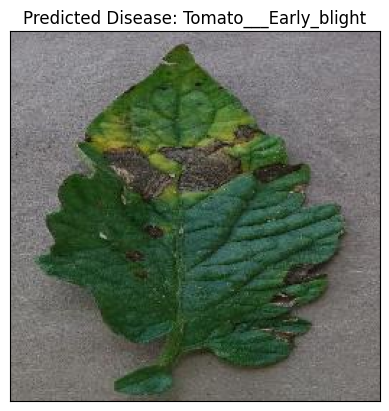

In [17]:
model_prediction=class_name[result_index]
plt.imshow(img)
plt.title(f"Predicted Disease: {model_prediction}")
plt.xticks([])
plt.yticks([])
plt.show()